In [1]:
import json
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Stage 1: Load Dataset and Ground Truth IDs
# ---------------------------------------------------------
dataset = load_dataset("pubmed_qa", "pqa_labeled")
with open('test_ground_truth.json', 'r') as f:
    ground_truth = json.load(f)
test_ids = set(ground_truth.keys()) 

In [3]:

# Stage 2: Split into Official Test and Development sets
# ---------------------------------------------------------
label_map = {"no": 0, "maybe": 1, "yes": 2}
dev_records = []
test_records = []
for row in dataset['train']:
    pubid_str = str(row['pubid']) 
    text = f"[QUESTION]: {row['question']} [CONTEXT]: {' '.join(row['context']['contexts'])}"
    label_numeric = label_map[row['final_decision']]
    data_point = {'text': text, 'label': label_numeric}
    if pubid_str in test_ids:
        test_records.append(data_point)
    else:
        dev_records.append(data_point)

df_dev = pd.DataFrame(dev_records)
df_test = pd.DataFrame(test_records)

X_dev, y_dev = df_dev['text'], df_dev['label']
X_test_final, y_test_final = df_test['text'], df_test['label']

In [4]:
# Stage 3: K-Fold Cross-Validation on Development Set
# ---------------------------------------------------------
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_acc = []
cv_f1 = []
all_test_probas = []

print("Starting 10-Fold CV on Development Data...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_dev, y_dev)):
    X_train_fold, X_val_fold = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
    y_train_fold, y_val_fold = y_dev.iloc[train_idx], y_dev.iloc[val_idx]

    tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(X_train_fold)
    X_val_tfidf = tfidf.transform(X_val_fold)

    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_train_tfidf, y_train_fold)
    y_pred = model.predict(X_val_tfidf)

    acc = accuracy_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    cv_acc.append(acc)
    cv_f1.append(f1)

    X_test_tfidf = tfidf.transform(X_test_final)
    test_proba = model.predict_proba(X_test_tfidf)
    all_test_probas.append(test_proba)

    print(f"Fold {fold+1}: Acc={acc:.3f}, F1={f1:.3f}")

Starting 10-Fold CV on Development Data...
Fold 1: Acc=0.600, F1=0.473
Fold 2: Acc=0.520, F1=0.314
Fold 3: Acc=0.600, F1=0.375
Fold 4: Acc=0.540, F1=0.348
Fold 5: Acc=0.460, F1=0.277
Fold 6: Acc=0.600, F1=0.394
Fold 7: Acc=0.540, F1=0.372
Fold 8: Acc=0.460, F1=0.363
Fold 9: Acc=0.580, F1=0.377
Fold 10: Acc=0.440, F1=0.302



DEV CV Mean Accuracy: 0.534
DEV CV Mean Macro F1: 0.359

OFFICIAL 10-FOLD BASELINE RESULTS (TEST SET)
              precision    recall  f1-score   support

          no       0.37      0.25      0.30       169
       maybe       0.00      0.00      0.00        55
         yes       0.56      0.76      0.64       276

    accuracy                           0.51       500
   macro avg       0.31      0.34      0.31       500
weighted avg       0.43      0.51      0.46       500



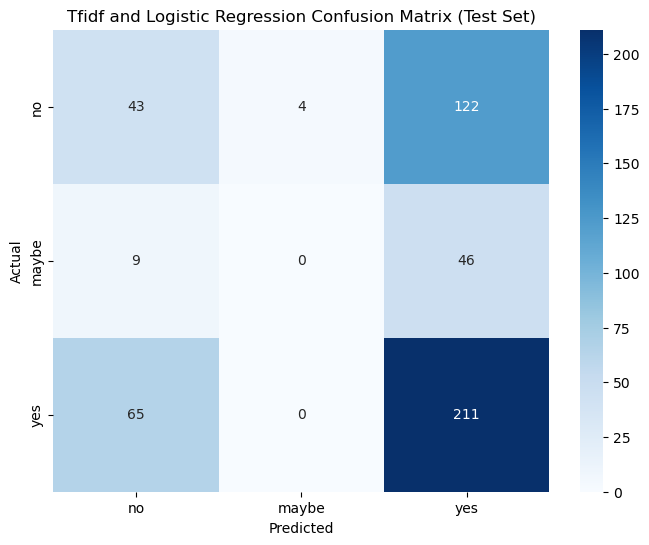

In [5]:
# Final Summary
# ---------------------------------------------------------
print(f"\n{'='*35}")
print(f"DEV CV Mean Accuracy: {np.mean(cv_acc):.3f}")
print(f"DEV CV Mean Macro F1: {np.mean(cv_f1):.3f}")
print(f"{'='*35}")

mean_test_probas = np.mean(all_test_probas, axis=0)
final_test_preds = np.argmax(mean_test_probas, axis=1)

print("\n" + "="*45)
print("OFFICIAL 10-FOLD BASELINE RESULTS (TEST SET)")
print("="*45)
print(classification_report(
    y_test_final, 
    final_test_preds, 
    target_names=["no", "maybe", "yes"]
))

cm = confusion_matrix(y_test_final, final_test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["no", "maybe", "yes"], 
            yticklabels=["no", "maybe", "yes"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tfidf and Logistic Regression Confusion Matrix (Test Set)')
plt.show()